In [480]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format='svg'

In [481]:
movies=pd.read_csv('movies.csv')
ratings=pd.read_csv('ratings2.csv')

In [482]:
users=pd.read_csv('users.csv')
info=pd.read_csv('info.csv')

In [483]:
users.columns=['Unamed: 0', 'user_id', 'gender', 'age', 'occupation', 'zipcode',
       'age_desc', 'occ_desc']

In [484]:
desc_set=[]
def occ(x):
    desc_set.append((set(x['occupation']),set(x['occ_desc'].values)))
users.groupby('occupation').apply(occ)

""


In [485]:
users=users[['user_id','gender','age','occupation']]

In [486]:
movies=movies[['movie_id','title','genres']]

In [487]:
movies.genres=movies.genres.apply(lambda x: x.split('|'))

In [488]:
movies.index=movies.movie_id
movies=movies.drop(columns='movie_id')

In [489]:
movies.loc[(3,'title')]

'Grumpier Old Men (1995)'

In [490]:
ratings=ratings.drop(columns='timestamp')

In [491]:
user_counts=ratings.groupby('user_id')['rating'].count()
user_counts=user_counts[user_counts>100]
ratings=ratings[ratings['user_id'].isin(user_counts.index)]
ratings

,user_id,movie_id,rating
53,2,1357,5
54,2,3068,4
55,2,1537,4
56,2,647,3
57,2,2194,4
...,...,...,...
1000204,6040,1091,1
1000205,6040,1094,5
1000206,6040,562,5
1000207,6040,1096,4


In [492]:
task2_df=pd.merge(ratings,users,left_on='user_id',right_on='user_id')

In [493]:
task2_df['movie_year']=task2_df['movie_id'].apply(lambda x: movies.loc[(x,'title')])

In [494]:
task2_df['movie_year']=task2_df['movie_year'].apply(lambda x: x[len(x)-3:len(x)-1:1])

In [495]:
task2_df['movie_genre']=task2_df['movie_id'].apply(lambda x: movies.loc[(x,'genres')])

In [496]:
task2_df['movie_year'] = task2_df['movie_year'].astype(int)
task2_df

,user_id,movie_id,rating,gender,age,occupation,movie_year,movie_genre
0,2,1357,5,M,56,16,96,"[Drama, Romance]"
1,2,3068,4,M,56,16,82,[Drama]
2,2,1537,4,M,56,16,96,[Comedy]
3,2,647,3,M,56,16,96,"[Drama, War]"
4,2,2194,4,M,56,16,87,"[Action, Crime, Drama]"
...,...,...,...,...,...,...,...,...
843697,6040,1091,1,M,25,6,89,[Comedy]
843698,6040,1094,5,M,25,6,92,"[Drama, Romance, War]"
843699,6040,562,5,M,25,6,95,"[Comedy, Drama]"
843700,6040,1096,4,M,25,6,82,[Drama]


In [497]:
task2_df.to_csv('task2_df.csv', index=False)

In [498]:
data=task2_df.groupby(['user_id','gender','age','occupation']).agg({'rating':'mean','movie_year':'mean'}).reset_index()

In [499]:
data_age=data.copy()

In [500]:
musical_ratings = task2_df[task2_df['movie_genre'].apply(lambda x: 'Musical' in x)].groupby('user_id')
musical = musical_ratings.agg({'rating': 'mean'}).rename(columns={'rating': 'musical_mean'})
data=pd.merge(data,musical,left_on='user_id',right_on='user_id')

In [501]:
data['musical_mean']=data['musical_mean']-data['rating']

###########存储data，不要再更改###############

In [502]:
data_full=data.copy()

In [503]:
western_ratings = task2_df[task2_df['movie_genre'].apply(lambda x: 'Western' in x)].groupby('user_id')
western = western_ratings.agg({'rating': 'mean'}).rename(columns={'rating': 'western_mean'})
data_full=pd.merge(data_full,western,left_on='user_id',right_on='user_id')
data_full

,user_id,gender,age,occupation,rating,movie_year,musical_mean,western_mean
0,5,M,25,20,3.146465,89.712121,0.186869,4.000000
1,8,M,25,12,3.884892,93.971223,0.115108,4.000000
2,10,F,35,1,4.114713,80.234414,0.317719,3.875000
3,11,F,25,1,3.277372,92.525547,0.389294,3.000000
4,13,M,45,1,3.388889,86.546296,0.111111,2.666667
...,...,...,...,...,...,...,...,...
2548,6035,F,25,1,2.610714,93.478571,-1.110714,2.333333
2549,6036,F,25,15,3.302928,85.041667,0.406749,3.642857
2550,6037,F,45,1,3.717822,75.193069,0.282178,3.750000
2551,6039,F,45,0,3.878049,66.170732,-0.187573,4.500000


In [504]:
data_full['western_mean']=data_full['western_mean']-data_full['rating']

In [505]:
western_counts = task2_df[task2_df['movie_genre'].apply(lambda x: 'Western' in x)].groupby('user_id')
western = western_ratings.agg({'rating': 'count'}).rename(columns={'rating': 'western_count'})
data_full=pd.merge(data_full,western,left_on='user_id',right_on='user_id')

In [506]:
action_count = task2_df[task2_df['movie_genre'].apply(lambda x: 'Action' in x)].groupby('user_id')
action = action_count.agg({'rating': 'count'}).rename(columns={'rating': 'action_count'})
data_full=pd.merge(data_full,action,left_on='user_id',right_on='user_id')

In [507]:
data_full['gender'] = data_full['gender'].apply(lambda x: 0 if x == 'F' else 1)

In [508]:
data_full.head(4)

,user_id,gender,age,occupation,rating,movie_year,musical_mean,western_mean,western_count,action_count
0,5,1,25,20,3.146465,89.712121,0.186869,0.853535,1,31
1,8,1,25,12,3.884892,93.971223,0.115108,0.115108,1,36
2,10,0,35,1,4.114713,80.234414,0.317719,-0.239713,8,81
3,11,0,25,1,3.277372,92.525547,0.389294,-0.277372,1,9


In [509]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold

In [510]:
X = data_full.iloc[:, -4:]
y = data_full['gender']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [511]:
param_grid = {
    'learning_rate': [0.01, 0.05,0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 3,5],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'n_estimators': [100]
}

xgb_model = XGBClassifier()
grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='f1_macro')
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.22      0.31       122
           1       0.79      0.94      0.86       389

    accuracy                           0.77       511
   macro avg       0.66      0.58      0.59       511
weighted avg       0.73      0.77      0.73       511



自然地推测，children's这类电影的观看情况与年龄强相关；年轻人也更倾向于看节奏更快、更有激情的电影，而不喜欢看节奏舒缓，偏文艺性的电影。

In [512]:
children_counts = task2_df[task2_df['movie_genre'].apply(lambda x: 'Children\'s' in x)].groupby('user_id')
children = children_counts.agg({'rating': 'count'}).rename(columns={'rating': 'children_count'})
data_age=pd.merge(data_age,children,left_on='user_id',right_on='user_id')

In [513]:
data_age.head(5)

,user_id,gender,age,occupation,rating,movie_year,children_count
0,5,M,25,20,3.146465,89.712121,6
1,8,M,25,12,3.884892,93.971223,3
2,9,M,25,17,3.735849,80.367925,5
3,10,F,35,1,4.114713,80.234414,64
4,11,F,25,1,3.277372,92.525547,6


In [514]:
age_groups = data_age.groupby('age')

In [515]:
less_10_proportion = age_groups.apply(lambda x: (x['children_count'] < 10).mean())
med_proportion=age_groups.apply(lambda x: ((x['children_count'] >= 10) & (x['children_count'] <= 50)).mean())
over_50_proportion = age_groups.apply(lambda x: (x['children_count'] > 50).mean())

In [516]:
over_80=age_groups.apply(lambda x:(x['movie_year'] > 80).mean())
med=age_groups.apply(lambda x: ((x['children_count'] >= 75) & (x['children_count'] <= 80)).mean())
less_75=age_groups.apply(lambda x:(x['movie_year'] <75).mean())

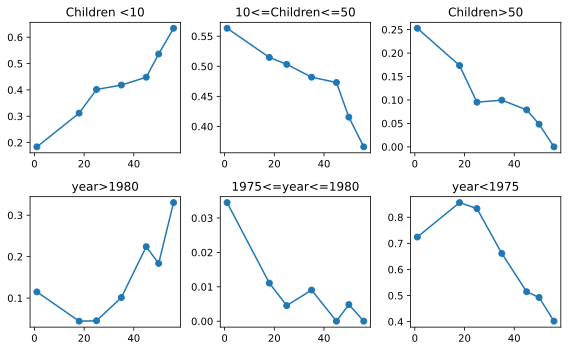

In [517]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)
ax6 = fig.add_subplot(2, 3, 6)

ax1.plot(less_10_proportion.index,less_10_proportion.values,'-o')
ax2.plot(med_proportion.index,med_proportion.values,'-o')
ax3.plot(over_50_proportion.index,over_50_proportion.values,'-o')
ax4.plot(less_75.index,less_75.values,'-o')
ax5.plot(med.index,med.values,'-o')
ax6.plot(over_80.index,over_80.values,'-o')

ax1.set_title('Children <10')
ax2.set_title('10<=Children<=50')
ax3.set_title('Children>50')
ax4.set_title('year>1980')
ax5.set_title('1975<=year<=1980')
ax6.set_title('year<1975')


plt.tight_layout()
plt.savefig('grade_1.png')
plt.show()

In [518]:
drama_counts = task2_df[task2_df['movie_genre'].apply(lambda x: 'Drama' in x)].groupby('user_id')
drama = drama_counts.agg({'rating': 'count'}).rename(columns={'rating': 'drama_count'})

In [519]:
data_age=pd.merge(data_age,drama,left_on='user_id',right_on='user_id')

In [520]:
ad_counts = task2_df[task2_df['movie_genre'].apply(lambda x: 'Adventure' in x)].groupby('user_id')
ad = ad_counts.agg({'rating': 'count'}).rename(columns={'rating': 'ad_count'})
data_age=pd.merge(data_age,ad,left_on='user_id',right_on='user_id')

In [521]:
age_groups=data_age.groupby('age')

In [522]:
less_20_proportion = age_groups.apply(lambda x: (x['drama_count'] < 20).mean())
med_proportion=age_groups.apply(lambda x: ((x['drama_count'] >= 20) & (x['drama_count'] <= 50)).mean())
over_50_proportion = age_groups.apply(lambda x: (x['drama_count'] > 50).mean())

In [523]:
age_groups = data_age.groupby('age')

In [524]:
less_5 = age_groups.apply(lambda x: (x['ad_count'] < 5).mean())
med = age_groups.apply(lambda x: ((x['ad_count'] >= 5) & (x['ad_count'] <= 100)).mean())
over_100 = age_groups.apply(lambda x: (x['ad_count'] > 100).mean())

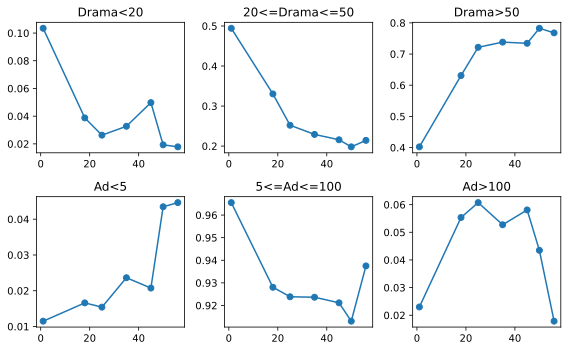

In [525]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)
ax6 = fig.add_subplot(2, 3, 6)

ax1.plot(less_20_proportion.index,less_20_proportion.values,'-o')
ax2.plot(med_proportion.index,med_proportion.values,'-o')
ax3.plot(over_50_proportion.index,over_50_proportion.values,'-o')
ax4.plot(less_5.index,less_5.values,'-o')
ax5.plot(med.index,med.values,'-o')
ax6.plot(over_100.index,over_100.values,'-o')

ax1.set_title('Drama<20')
ax2.set_title('20<=Drama<=50')
ax3.set_title('Drama>50')
ax4.set_title('Ad<5')
ax5.set_title('5<=Ad<=100')
ax6.set_title('Ad>100')


plt.tight_layout()
plt.savefig('grade_2.png')
plt.tight_layout()

In [526]:
bins = [0, 5, 20, 50, 100, np.inf] 
labels = [1, 2, 3, 4,5]

In [527]:
#data_age['children_label'] = pd.cut(data_age['children_count'], bins=bins, labels=labels, include_lowest=True).map({1: 'class_1', 2: 'class_2', 3: 'class_3', 4: 'class_4',5:'class 5'})

In [528]:
#data_age['drama_label'] = pd.cut(data_age['drama_count'], bins=bins, labels=labels, include_lowest=True).map({1: 'class_1', 2: 'class_2', 3: 'class_3', 4: 'class_4',5:'class_5'})

In [529]:
#data_age['ad_label'] = pd.cut(data_age['ad_count'], bins=bins, labels=labels, include_lowest=True).map({1: 'class_1', 2: 'class_2', 3: 'class_3', 4: 'class_4',5:'class_5'})

In [530]:
def label_movie_year(row):
    if row['movie_year'] < 75:
        return 'old_movie'
    elif row['movie_year'] > 80:
        return 'new_movie'
    else:
        return 'med_movie'
data_age['movie_year_label'] = data_age.apply(lambda row: label_movie_year(row), axis=1)

In [531]:
def label_children_count(row):
    if row['children_count'] < 10:
        return 'no_children'
    elif row['children_count'] > 50:
        return 'like_children'
    else:
        return 'med_children'

data_age['children_count_label'] = data_age.apply(lambda row: label_children_count(row), axis=1)

In [532]:
def label_drama_count(row):
    if row['drama_count'] < 20:
        return 'no_drama'
    elif row['drama_count'] > 50:
        return 'like_drama'
    else:
        return 'med_drama'

data_age['drama_count_label'] = data_age.apply(lambda row: label_drama_count(row), axis=1)

In [533]:
def label_ad_count(row):
    if row['ad_count'] < 5:
        return 'no_ad'
    elif row['ad_count'] > 100:
        return 'like_ad'
    else:
        return 'med_ad'

data_age['ad_count_label'] = data_age.apply(lambda row: label_ad_count(row), axis=1)

In [534]:
data_age.columns

Index(['user_id', 'gender', 'age', 'occupation', 'rating', 'movie_year',
       'children_count', 'drama_count', 'ad_count', 'movie_year_label',
       'children_count_label', 'drama_count_label', 'ad_count_label'],
      dtype='object')

In [542]:
agee=data_age[['age','movie_year_label',
       'children_count_label', 'drama_count_label', 'ad_count_label']]

In [543]:
agee

,age,movie_year_label,children_count_label,drama_count_label,ad_count_label
0,25,new_movie,no_children,like_drama,med_ad
1,25,new_movie,no_children,like_drama,med_ad
2,25,new_movie,no_children,like_drama,med_ad
3,35,new_movie,like_children,like_drama,med_ad
4,25,new_movie,no_children,like_drama,med_ad
...,...,...,...,...,...
2837,25,new_movie,med_children,like_drama,med_ad
2838,25,new_movie,like_children,like_drama,med_ad
2839,45,med_movie,no_children,like_drama,med_ad
2840,45,old_movie,med_children,med_drama,med_ad


In [544]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [545]:
le = LabelEncoder()
agee= agee.apply(le.fit_transform)
agee

,age,movie_year_label,children_count_label,drama_count_label,ad_count_label
0,2,1,2,0,1
1,2,1,2,0,1
2,2,1,2,0,1
3,3,1,0,0,1
4,2,1,2,0,1
...,...,...,...,...,...
2837,2,1,1,0,1
2838,2,1,0,0,1
2839,4,0,2,0,1
2840,4,2,1,1,1


In [561]:
X =agee.drop('age', axis=1)
y=agee['age']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [562]:
rf = RandomForestClassifier(n_estimators=5, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc =accuracy_score(y_test, rf_pred)
rf_acc

0.421792618629174

In [567]:
recall_score(y_test, rf_pred, average='macro')

0.18425537679974166